# UFF Optimization: RDKit (CPU) vs nvMolKit (GPU)

**Tutorial 5 of the nvMolKit acceleration series.**

The [Universal Force Field (UFF)](https://www.rdkit.org/docs/source/rdkit.Chem.rdForceFieldHelpers.html) is a
lighter, broadly-applicable alternative to MMFF94 (Tutorial 4) that has parameters for essentially the whole
periodic table. As with MMFF, energy-minimizing *many conformers across many molecules* is an independent batch
that nvMolKit runs on the GPU.

This notebook compares:

- **RDKit (CPU)** — `AllChem.UFFOptimizeMoleculeConfs(mol, ...)` per molecule (single- and multi-threaded).
- **nvMolKit (GPU)** — `nvmolkit.uffOptimization.UFFOptimizeMoleculesConfs(mols, ...)`, batched.

Both backends start from **identical conformers** and use the **same UFF settings**, so we compare the optimized
per-conformer energies directly. The molecule count is intentionally small — a handful already shows a
several-fold speedup.

> **Gotchas (same as MMFF):** import `nvmolkit.types` *before* `nvmolkit.uffOptimization` (else a
> `BatchHardwareOptions` converter error), and keep only molecules that embedded the full conformer set (an
> empty conformer set makes RDKit raise `Bad Conformer Id`). Run from this `examples/tutorials/` directory.


## 1. Setup and GPU check

In [1]:
import copy
import time

import numpy as np
import pandas as pd
import torch
from rdkit import RDLogger
from rdkit.Chem import MolFromSmiles, AddHs, AllChem
from rdkit.Chem.rdDistGeom import ETKDGv3, EmbedMultipleConfs

import nvmolkit
from nvmolkit.types import HardwareOptions                     # import BEFORE uffOptimization
from nvmolkit.uffOptimization import UFFOptimizeMoleculesConfs

RDLogger.DisableLog("rdApp.*")
assert torch.cuda.is_available(), "CUDA is not available - check your torch/driver install."
print(f"nvmolkit : {nvmolkit.__version__}")
print(f"torch    : {torch.__version__}")
print(f"GPU      : {torch.cuda.get_device_name(0)}")

nvmolkit : 0.5.0
torch    : 2.12.0+cu126
GPU      : NVIDIA A100 80GB PCIe


## 2. Parameters

In [2]:
CONFS_PER_MOL = 10
N_CPU_THREADS = 16
RANDOM_SEED = 42
MAX_ITERS = 200
VDW_THRESHOLD = 10.0
SIZES = [10, 25, 50]                 # number of molecules (small set; speedup shows quickly)
MIN_HEAVY, MAX_HEAVY = 15, 30
SMI_FILE = "../../benchmarks/data/chembl_10k.smi"
print(f"confs/mol={CONFS_PER_MOL}, maxIters={MAX_ITERS}, vdwThreshold={VDW_THRESHOLD}, sizes={SIZES}")

confs/mol=10, maxIters=200, vdwThreshold=10.0, sizes=[10, 25, 50]


## 3. Load molecules and generate the starting conformers (once)

We keep normal-sized molecules that have full UFF parameters and that successfully embed all `CONFS_PER_MOL`
conformers. This shared conformer set is the starting point for both backends; conformer generation is not part
of the timed comparison.

In [3]:
smis = pd.read_csv(SMI_FILE, header=None, nrows=10000).iloc[:, 0].tolist()
params = ETKDGv3(); params.randomSeed = RANDOM_SEED

mols_all = []
for s in smis:
    m = MolFromSmiles(s)
    if m is None or not (MIN_HEAVY <= m.GetNumHeavyAtoms() <= MAX_HEAVY):
        continue
    mh = AddHs(m)
    if not AllChem.UFFHasAllMoleculeParams(mh):
        continue
    EmbedMultipleConfs(mh, numConfs=CONFS_PER_MOL, params=params)
    if mh.GetNumConformers() == CONFS_PER_MOL:      # skip embedding failures (avoids 'Bad Conformer Id')
        mols_all.append(mh)
    if len(mols_all) >= max(SIZES):
        break
SIZES = [n for n in SIZES if n <= len(mols_all)]
print(f"Prepared {len(mols_all)} molecules x {CONFS_PER_MOL} conformers; sweep sizes = {SIZES}")

Prepared 50 molecules x 10 conformers; sweep sizes = [10, 25, 50]


## 4. Define the two backends

Each call optimizes *fresh copies* (same starting coordinates) and returns the flat array of optimized
per-conformer energies.

In [4]:
def fresh_copies(mols):
    return [copy.deepcopy(m) for m in mols]


def rdkit_uff(mols, num_threads=1):
    energies = []
    for m in mols:
        res = AllChem.UFFOptimizeMoleculeConfs(
            m, numThreads=num_threads, maxIters=MAX_ITERS,
            vdwThresh=VDW_THRESHOLD, ignoreInterfragInteractions=True,
        )
        energies.extend(e for _, e in res)
    return np.array(energies)


def nvmolkit_uff(mols):
    ll = UFFOptimizeMoleculesConfs(
        mols, maxIters=MAX_ITERS, vdwThreshold=VDW_THRESHOLD,
        ignoreInterfragInteractions=True,
        hardwareOptions=HardwareOptions(preprocessingThreads=N_CPU_THREADS),
    )
    torch.cuda.synchronize()
    return np.array([e for sub in ll for e in sub])

## 5. Correctness check (optimized energies)

Same start, same force field, same iteration cap -> the optimized energies should agree closely.

In [5]:
sample = mols_all[:max(SIZES)]
rd_e = rdkit_uff(fresh_copies(sample), num_threads=N_CPU_THREADS)
nv_e = nvmolkit_uff(fresh_copies(sample))

diff = np.abs(rd_e - nv_e)
print(f"conformers compared : {len(rd_e)}")
print(f"mean |Delta E|      : {diff.mean():.4f} kcal/mol")
print(f"median |Delta E|    : {np.median(diff):.4f} kcal/mol")
print(f"max  |Delta E|      : {diff.max():.3f} kcal/mol")
print(f"correlation         : {np.corrcoef(rd_e, nv_e)[0, 1]:.6f}")
print("\n(A few conformers settle in slightly different nearby minima - expected for independent minimizers.)")

conformers compared : 500
mean |Delta E|      : 0.0001 kcal/mol
median |Delta E|    : 0.0000 kcal/mol
max  |Delta E|      : 0.017 kcal/mol
correlation         : 1.000000

(A few conformers settle in slightly different nearby minima - expected for independent minimizers.)


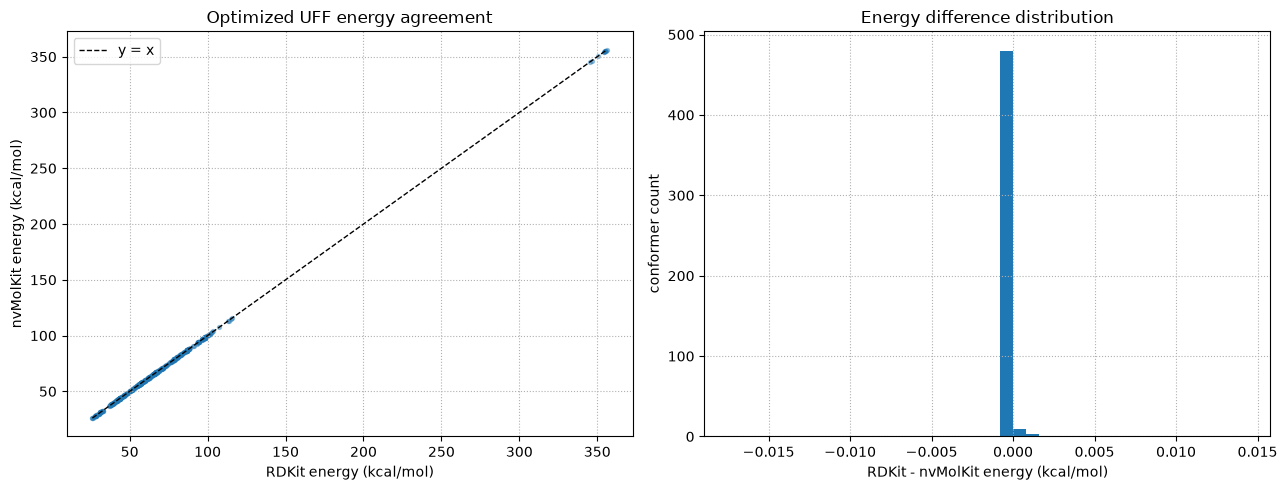

In [6]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
lo, hi = min(rd_e.min(), nv_e.min()), max(rd_e.max(), nv_e.max())
ax1.scatter(rd_e, nv_e, s=8, alpha=0.4)
ax1.plot([lo, hi], [lo, hi], "k--", lw=1, label="y = x")
ax1.set_xlabel("RDKit energy (kcal/mol)")
ax1.set_ylabel("nvMolKit energy (kcal/mol)")
ax1.set_title("Optimized UFF energy agreement")
ax1.legend(); ax1.grid(True, ls=":")

ax2.hist(rd_e - nv_e, bins=40)
ax2.set_xlabel("RDKit - nvMolKit energy (kcal/mol)")
ax2.set_ylabel("conformer count")
ax2.set_title("Energy difference distribution")
ax2.grid(True, ls=":")
plt.tight_layout(); plt.show()

## 6. Warm up the GPU

In [7]:
_ = nvmolkit_uff(fresh_copies(mols_all[:5]))
print("GPU warmed up.")

GPU warmed up.


## 7. Scaling benchmark

We time only the UFF optimization (conformers are precomputed).

In [8]:
def timed(fn, mols):
    t = time.perf_counter()
    fn(mols)
    torch.cuda.synchronize()
    return time.perf_counter() - t


rows = []
for n in SIZES:
    base = mols_all[:n]
    t_rd1 = timed(lambda m: rdkit_uff(m, num_threads=1), fresh_copies(base))
    t_rdN = timed(lambda m: rdkit_uff(m, num_threads=N_CPU_THREADS), fresh_copies(base))
    t_gpu = timed(nvmolkit_uff, fresh_copies(base))
    total_confs = n * CONFS_PER_MOL
    rows.append({
        "n_mols": n,
        "total_confs": total_confs,
        "rdkit_1thread_s": t_rd1,
        f"rdkit_{N_CPU_THREADS}thread_s": t_rdN,
        "nvmolkit_gpu_s": t_gpu,
        "gpu_confs_per_s": total_confs / t_gpu,
        "speedup_vs_1thread": t_rd1 / t_gpu,
        f"speedup_vs_{N_CPU_THREADS}thread": t_rdN / t_gpu,
    })
    print(f"n={n:4d} | confs={total_confs:5d} | RDKit-1t {t_rd1:7.2f}s | "
          f"RDKit-{N_CPU_THREADS}t {t_rdN:6.2f}s | nvMolKit {t_gpu:6.3f}s | "
          f"speedup {t_rd1/t_gpu:6.1f}x / {t_rdN/t_gpu:5.1f}x")

df = pd.DataFrame(rows)
df

n=  10 | confs=  100 | RDKit-1t    1.99s | RDKit-16t   0.38s | nvMolKit  0.091s | speedup   21.9x /   4.1x


n=  25 | confs=  250 | RDKit-1t    5.40s | RDKit-16t   1.01s | nvMolKit  0.175s | speedup   31.0x /   5.8x


n=  50 | confs=  500 | RDKit-1t   11.23s | RDKit-16t   2.10s | nvMolKit  0.342s | speedup   32.9x /   6.1x


,n_mols,total_confs,rdkit_1thread_s,rdkit_16thread_s,nvmolkit_gpu_s,gpu_confs_per_s,speedup_vs_1thread,speedup_vs_16thread
0,10,100,1.992817,0.376263,0.090810,1101.199059,21.944887,4.143402
1,25,250,5.403918,1.007206,0.174548,1432.274439,30.959577,5.770384
2,50,500,11.232107,2.097990,0.341561,1463.868549,32.884655,6.142364


## 8. Plot: runtime and speedup vs number of molecules

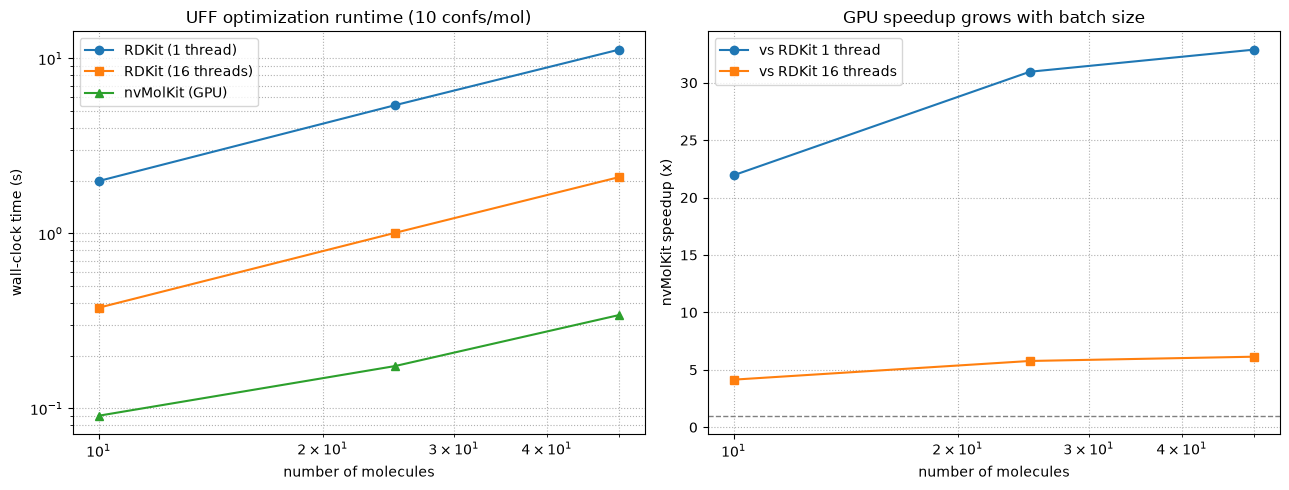

In [9]:
col_rdN = f"rdkit_{N_CPU_THREADS}thread_s"
col_spN = f"speedup_vs_{N_CPU_THREADS}thread"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(df["n_mols"], df["rdkit_1thread_s"], "o-", label="RDKit (1 thread)")
ax1.plot(df["n_mols"], df[col_rdN], "s-", label=f"RDKit ({N_CPU_THREADS} threads)")
ax1.plot(df["n_mols"], df["nvmolkit_gpu_s"], "^-", label="nvMolKit (GPU)")
ax1.set_xlabel("number of molecules")
ax1.set_ylabel("wall-clock time (s)")
ax1.set_title(f"UFF optimization runtime ({CONFS_PER_MOL} confs/mol)")
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.legend(); ax1.grid(True, which="both", ls=":")

ax2.plot(df["n_mols"], df["speedup_vs_1thread"], "o-", label="vs RDKit 1 thread")
ax2.plot(df["n_mols"], df[col_spN], "s-", label=f"vs RDKit {N_CPU_THREADS} threads")
ax2.axhline(1.0, color="gray", ls="--", lw=1)
ax2.set_xlabel("number of molecules")
ax2.set_ylabel("nvMolKit speedup (x)")
ax2.set_title("GPU speedup grows with batch size")
ax2.set_xscale("log")
ax2.legend(); ax2.grid(True, which="both", ls=":")
plt.tight_layout(); plt.show()

## 9. Takeaways

- **Same minima.** Optimized UFF energies match RDKit to a fraction of a kcal/mol on average.
- **Several-fold speedup from a handful of molecules**, growing with the batch — like MMFF, UFF minimization is
  an independent-per-conformer workload the GPU batches efficiently.
- **Same practical notes as MMFF.** Import `nvmolkit.types` first; keep only fully-embedded molecules. UFF has
  parameters for nearly all molecules, so the parameter filter rarely drops anything.
- **Drop-in swap.** UFF and MMFF share the same call shape — switch force fields by changing one import.

**Next:** Tutorial 6 covers the batched force field with custom options and constraints.